In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

PATH = '/Users/hncha/Desktop/QTM 350/datasci350-project/data/raw/Total trained teachers in secondary education.csv'

KEEP_CODES = (
    'AFE', 'AFW', 'ARB', 'AUS', 'EAS', 'EUU',
    'LCN', 'NAC', 'SAS', 'LIC', 'LMC', 'UMC', 'HIC'
)
ID_COLS = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
YEAR_COLS = [str(year) for year in range(2000, 2024)]

raw = pd.read_csv(PATH, skiprows=4, encoding='utf-8-sig')
available_years = [col for col in YEAR_COLS if col in raw.columns]
keep_cols = ID_COLS + available_years

con = sqlite3.connect(':memory:')
raw[keep_cols].to_sql('teachers_raw', con, index=False, if_exists='replace')

266

In [3]:
# Load data
raw = pd.read_csv(PATH, skiprows=4, encoding='utf-8-sig')

available_years = [col for col in YEAR_COLS if col in raw.columns]
keep_cols = ID_COLS + available_years

con = sqlite3.connect(':memory:')
raw[keep_cols].to_sql('teachers_raw', con, index=False, if_exists='replace')

select_cols = ',\n        '.join([f'"{col}"' for col in keep_cols])
code_list = ', '.join([f"'{code}'" for code in KEEP_CODES])

query = f'''
SELECT DISTINCT
    {select_cols}
FROM teachers_raw
WHERE "Country Code" IN ({code_list})
ORDER BY "Country Code"
'''

total_trained_cleaned = pd.read_sql_query(query, con)

print('Cleaned shape:', total_trained_cleaned.shape)
display(total_trained_cleaned)

Cleaned shape: (13, 28)


,Country Name,Country Code,Indicator Name,Indicator Code,2000,2001,2002,2003,2004,2005,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,56.261650,56.311920,61.489079,62.512741,66.432060,62.232140,57.660271,58.947781,NaN,NaN
1,Africa Western and Central,AFW,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,81.352081,77.413940,83.131790,79.401619,...,58.750542,60.146420,63.261471,63.964119,64.058708,62.707390,61.438400,60.096371,58.627949,NaN
2,Arab World,ARB,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,82.428848,82.102058,84.530540,86.673569,86.625153,84.914467,86.515480,89.137039,83.607536
3,Australia,AUS,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,East Asia & Pacific,EAS,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,European Union,EUU,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,High income,HIC,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,95.330582,94.546288,93.504913,93.231010,92.342033,91.751877,91.503288,89.713600,87.844498,87.240913
7,Latin America & Caribbean,LCN,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,77.908272,78.789131,79.288857,80.404510,80.495323,79.849892,80.143822,80.488190,76.915817,75.870308
8,Low income,LIC,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,56.086391,58.217758,59.266510,60.343109,63.802670,59.730400,54.935242,55.617290,NaN,NaN
9,Lower middle income,LMC,Trained teachers in secondary education (% of ...,SE.SEC.TCAQ.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,78.663429,78.954407,83.919029,78.234596,80.452164,84.498154,83.087379,81.905449


In [4]:
union_query = '\nUNION ALL\n'.join([
    f'''
    SELECT
        "Country Name" AS country_name,
        "Country Code" AS country_code,
        {year} AS year,
        "{year}" AS trained_teacher
    FROM teachers_raw
    WHERE "Country Code" IN ({code_list})
    '''
    for year in available_years
])

query = f'''
SELECT DISTINCT
    country_name,
    country_code,
    year,
    trained_teacher
FROM (
    {union_query}
)
ORDER BY country_code, year
'''

total_trained_long = pd.read_sql_query(query, con)
print('Long shape:', total_trained_long.shape)
display(total_trained_long)

Long shape: (312, 4)


,country_name,country_code,year,trained_teacher
0,Africa Eastern and Southern,AFE,2000,NaN
1,Africa Eastern and Southern,AFE,2001,NaN
2,Africa Eastern and Southern,AFE,2002,NaN
3,Africa Eastern and Southern,AFE,2003,NaN
4,Africa Eastern and Southern,AFE,2004,NaN
...,...,...,...,...
307,Upper middle income,UMC,2019,NaN
308,Upper middle income,UMC,2020,NaN
309,Upper middle income,UMC,2021,NaN
310,Upper middle income,UMC,2022,81.004143


In [5]:
output_path = '/Users/hncha/Desktop/QTM 350/datasci350-project/data/cleaned/total_trained_teachers_secondary_cleaned.csv'
total_trained_long.to_csv(output_path, index=False)
print(f'Saved to: {output_path}')

#con.close()

Saved to: /Users/hncha/Desktop/QTM 350/datasci350-project/data/cleaned/total_trained_teachers_secondary_cleaned.csv


In [6]:
# EDA and Desriptive Statistics
import sqlite3
import pandas as pd

con = sqlite3.connect(':memory:')

total_trained_long.to_sql('teachers_long', con, index=False, if_exists='replace')

overall_stats = pd.read_sql_query('''
WITH base AS (
    SELECT CAST(trained_teacher AS REAL) AS trained_teacher
    FROM teachers_long
    WHERE trained_teacher IS NOT NULL
),
ordered AS (
    SELECT
        trained_teacher,
        ROW_NUMBER() OVER (ORDER BY trained_teacher) AS rn,
        COUNT(*) OVER () AS n
    FROM base
)
SELECT
    (SELECT COUNT(*) FROM base) AS count,
    (SELECT AVG(trained_teacher) FROM base) AS mean,
    (SELECT MIN(trained_teacher) FROM base) AS min,
    (SELECT MAX(trained_teacher) FROM base) AS max,
    (SELECT AVG(trained_teacher)
     FROM ordered
     WHERE rn IN ((n + 1) / 2, (n + 2) / 2)) AS median
''', con)

display(overall_stats)



,count,mean,min,max,median
0,126,78.666739,45.500069,99.87513,80.428337


In [7]:
pd.read_sql_query('''
SELECT
    COUNT(*) AS total_rows,
    COUNT(trained_teacher) AS non_missing_trained_teacher
FROM teachers_long
''', con)

,total_rows,non_missing_trained_teacher
0,312,126


In [8]:
pd.read_sql_query("SELECT DISTINCT country_code FROM teachers_long ORDER BY country_code", con)

,country_code
0,AFE
1,AFW
2,ARB
3,AUS
4,EAS
5,EUU
6,HIC
7,LCN
8,LIC
9,LMC


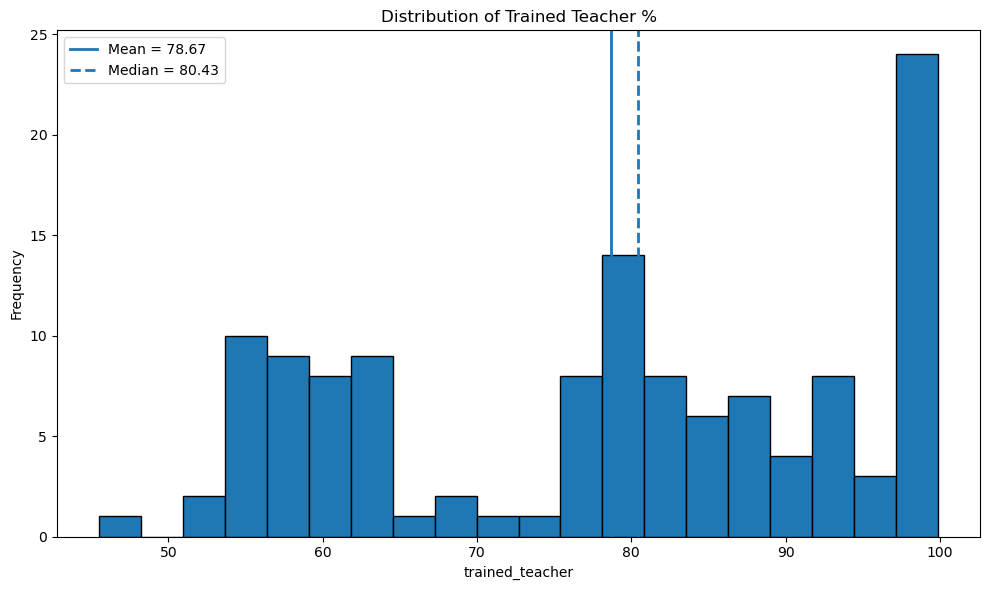

In [13]:
plot_data = total_trained_long.copy()
plot_data['trained_teacher'] = pd.to_numeric(plot_data['trained_teacher'], errors='coerce')
plot_data['year'] = pd.to_numeric(plot_data['year'], errors='coerce')
plot_data = plot_data.dropna(subset=['trained_teacher', 'year'])

mean_val = plot_data['trained_teacher'].mean()
median_val = plot_data['trained_teacher'].median()

plt.figure(figsize=(10, 6))
plt.hist(plot_data['trained_teacher'], bins=20, edgecolor='black')
plt.axvline(mean_val, linewidth=2, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, linewidth=2, linestyle='--', label=f'Median = {median_val:.2f}')

plt.title('Distribution of Trained Teacher %')
plt.xlabel('trained_teacher')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

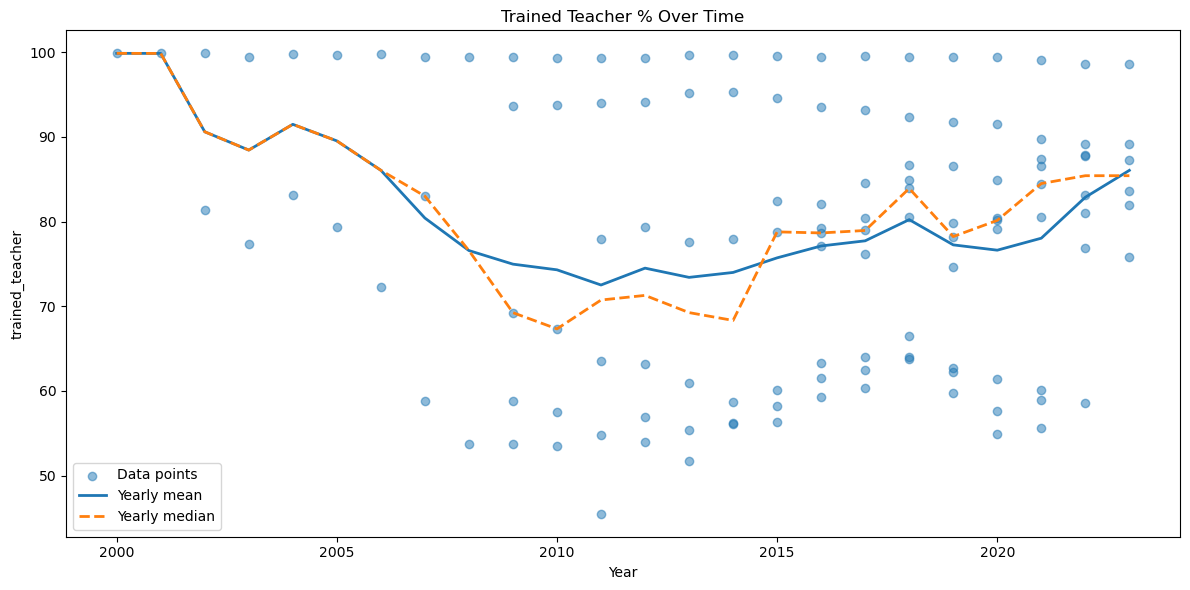

In [12]:
plot_data = total_trained_long.copy()
plot_data['trained_teacher'] = pd.to_numeric(plot_data['trained_teacher'], errors='coerce')
plot_data['year'] = pd.to_numeric(plot_data['year'], errors='coerce')
plot_data = plot_data.dropna(subset=['trained_teacher', 'year'])

year_summary = (
    plot_data
    .groupby('year')['trained_teacher']
    .agg(['mean', 'median'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.scatter(
    plot_data['year'],
    plot_data['trained_teacher'],
    alpha=0.5,
    label='Data points'
)

plt.plot(
    year_summary['year'],
    year_summary['mean'],
    linewidth=2,
    label='Yearly mean'
)

plt.plot(
    year_summary['year'],
    year_summary['median'],
    linewidth=2,
    linestyle='--',
    label='Yearly median'
)

plt.title('Trained Teacher % Over Time')
plt.xlabel('Year')
plt.ylabel('trained_teacher')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
#con.close()